In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display, clear_output
import sys
from pathlib import Path
import importlib
import ast
import re

# Ajusta path para importar src mesmo quando o notebook esta em /notebooks
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import guitar_brain as gb
importlib.reload(gb)

# --- VISUALIZACAO MINIMALISTA ---
def draw_fretboard(shape, title="Acorde", ax=None):
    frets = shape['frets']
    active_frets = [f for f in frets if f > 0]

    # Define viewport
    if active_frets:
        min_f = min(active_frets)
        start_fret = max(1, min_f - 1)
        # Se for muito agudo (>12), ajusta, se for grave (0-3), fixa
        if min_f <= 3: start_fret = 1
    else:
        start_fret = 1

    end_fret = start_fret + 4

    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 4))

    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(end_fret + 0.5, start_fret - 0.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Titulo
    ax.set_title(title, fontsize=10, pad=10)

    # Cordas e Trastes
    for i in range(1, 7):
        ax.plot([i, i], [start_fret - 0.5, end_fret + 0.5], color='#999999', linewidth=1)
    for i in range(start_fret, end_fret + 2):
        ax.plot([0.5, 6.5], [i - 0.5, i - 0.5], color='#666666', linewidth=1)

    # Pestana (nut)
    if start_fret == 1:
        ax.plot([0.5, 6.5], [0.5, 0.5], color='black', linewidth=4)

    # Numeracao lateral
    ax.text(0.2, start_fret, str(start_fret), va='center', ha='center', fontsize=8)

    for string_idx, fret in enumerate(frets):
        x_pos = string_idx + 1

        # Mute (X)
        if fret == -1:
            ax.text(x_pos, start_fret - 0.7, 'x', ha='center', va='center', color='red', fontsize=10)

        # Corda Solta (Sem bolinha)
        elif fret == 0:
            pass

        # Nota Apertada
        else:
            note_val = gb.TUNING_VALUES[string_idx] + fret
            note_name = gb.get_note_name(note_val)
            color = '#ff7f0e' if note_name == shape['root'] else '#1f77b4'

            circle = patches.Circle((x_pos, fret), 0.25, color=color, zorder=10)
            ax.add_patch(circle)
            ax.text(x_pos, fret, note_name, color='white', ha='center', va='center', fontsize=7, fontweight='bold')

# --- UTILITARIOS ---
def chord_label(root, quality):
    if quality == 'Major':
        return root
    return f"{root}{quality}"

def bass_note(shape):
    for i, f in enumerate(shape['frets']):
        if f != -1:
            return gb.get_note_name(gb.TUNING_VALUES[i] + f)
    return None

# --- PLAYLISTS DE TESTE ---
progressions = {
    'I-V-vi-IV (C)': [('C', 'Major'), ('G', 'Major'), ('A', 'm'), ('F', 'Major')],
    'ii-V-I (C)': [('D', 'm'), ('G', 'Major'), ('C', 'Major')],
    'CAGED basico (C-G-D-A-E)': [('C', 'Major'), ('G', 'Major'), ('D', 'Major'), ('A', 'Major'), ('E', 'Major')],
    'Pop (G)': [('G', 'Major'), ('D', 'Major'), ('E', 'm'), ('C', 'Major')],
    'Rock (A)': [('A', 'Major'), ('D', 'Major'), ('E', 'Major')],
    'Em-A-D-G (circulo)': [('E', 'm'), ('A', 'Major'), ('D', 'Major'), ('G', 'Major')],
    'Extended (7/9/sus)': [('A', '7'), ('D', '9'), ('G', '7sus4'), ('C', 'maj7')],
    'Diminutos e alterados': [('B', 'm7b5'), ('E', '7b9'), ('A', 'm')],
}

# Opcao customizada (texto em Python)
def parse_custom(text):
    try:
        prog = ast.literal_eval(text)
        if not isinstance(prog, list):
            raise ValueError('Formato esperado: lista')
    except Exception as e:
        print(f"Erro no custom: {e}")
        return None

    if all(isinstance(x, str) for x in prog):
        parsed = []
        for token in prog:
            out = gb.parse_chord_symbol(token)
            if not out:
                continue
            root, quality, _ = out
            parsed.append((root, quality))
        return parsed

    if all(isinstance(x, (list, tuple)) and len(x) >= 2 for x in prog):
        result = []
        for root, quality, *rest in prog:
            root = gb.normalize_root_name(root)
            result.append((root, quality))
        return result

    print('Custom invalido: use lista de strings ou lista de tuplas')
    return None

# --- PARSER DE CIFRA (texto bruto) ---
CHORD_TOKEN_RE = re.compile(r"[A-Ga-g](?:#|b|\u266f|\u266d)?[^\s]*")


def parse_chord_token(token):
    parsed = gb.parse_chord_symbol(token)
    if not parsed:
        return None
    root, quality, simplified = parsed
    return (root, quality, simplified, token)


def parse_chart_text(text):
    chords = []
    simplified = []
    skipped = []

    for token in CHORD_TOKEN_RE.findall(text):
        parsed = parse_chord_token(token)
        if not parsed:
            continue
        root, quality, simp, original = parsed
        chords.append((root, quality))
        if simp:
            simplified.append(original)

    return chords, simplified, skipped


def parse_chart_file(file_path):
    try:
        text = Path(file_path).read_text(encoding='utf-8', errors='ignore')
    except Exception as e:
        print(f"Erro lendo arquivo: {e}")
        return [], [], []

    return parse_chart_text(text)

# --- RENDER ---
def render_path(modo, musica, show_debug=False):
    pesos = {
        'Matematico Puro (Shortest Path)': 0.0,
        'Hibrido (Balanceado)': 2.0,
        'Tradicional (Prioriza CAGED)': 10.0
    }
    w = pesos[modo]

    caminho = gb.find_best_path(musica, complexity_weight=w)
    if not caminho:
        print("Caminho nao encontrado!")
        return

    print(f"Modo: {modo} (Peso de Complexidade: {w})")

    if show_debug:
        for i, step in enumerate(caminho):
            label = chord_label(step['root'], step['quality'])
            bnote = bass_note(step)
            is_caged = step.get('is_caged', gb._is_caged_shape(step))
            print(
                f"{i+1}. {label} | pos={step['position']:.2f} | dedos={gb.count_fingers(step)} "
                f"| caged={is_caged} | baixo={bnote} | frets={step['frets']}"
            )

    # Grid de plots
    cols = 3
    rows = (len(caminho) // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows*4))
    axes = axes.flatten()

    for i, step in enumerate(caminho):
        nome = chord_label(step['root'], step['quality'])
        draw_fretboard(step, title=f"{i+1}. {nome}", ax=axes[i])

    # Limpa plots vazios
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


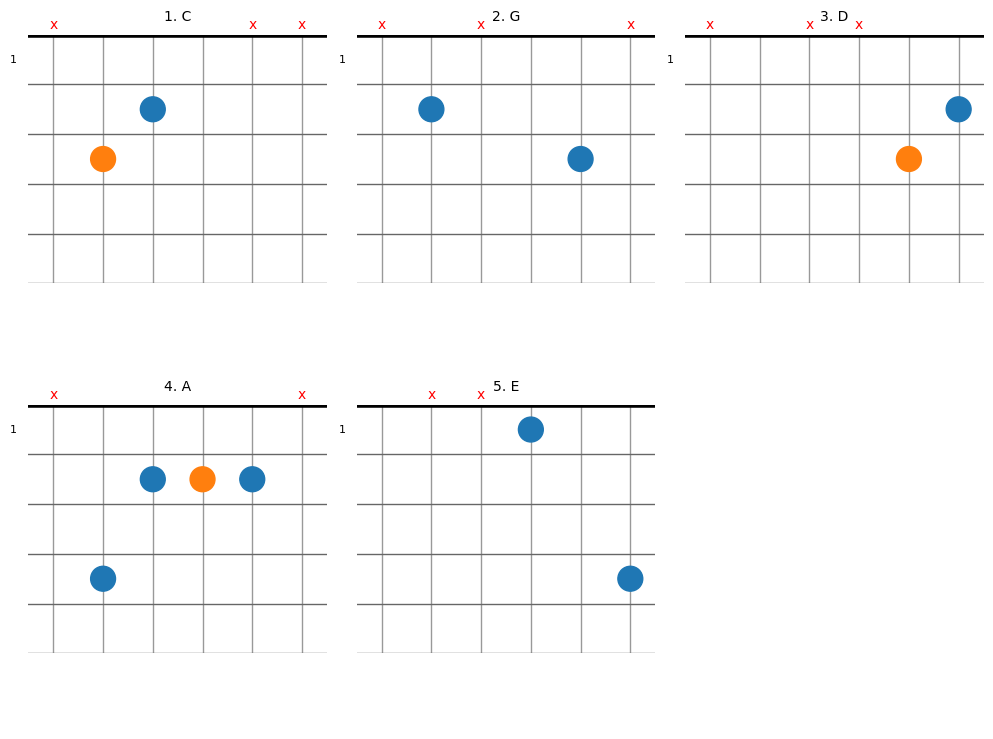

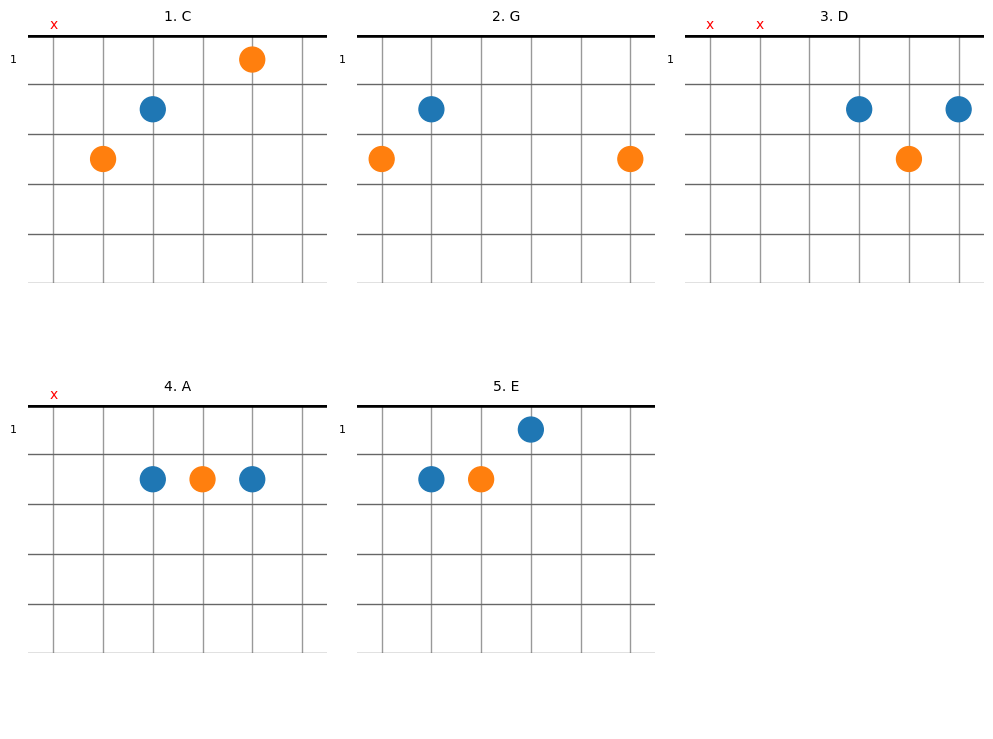

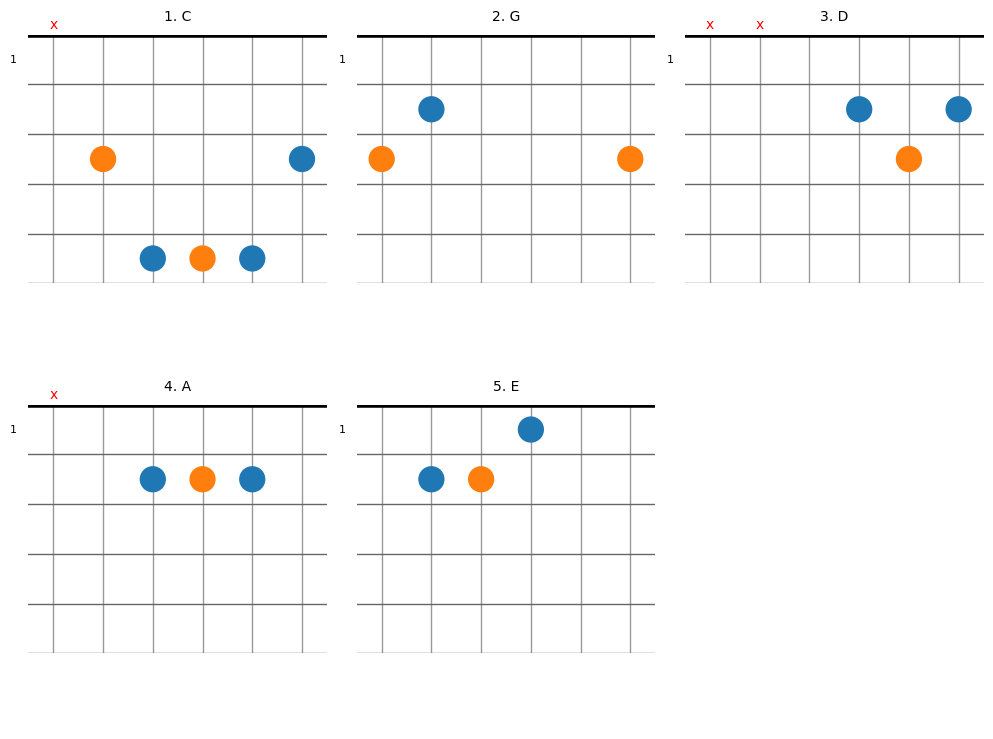

In [2]:
# --- INTERFACE ---

estilo = widgets.Dropdown(
    options=['Matematico Puro (Shortest Path)', 'Hibrido (Balanceado)', 'Tradicional (Prioriza CAGED)'],
    value='Tradicional (Prioriza CAGED)',
    description='Estilo:',
    disabled=False,
)

progressao = widgets.Dropdown(
    options=list(progressions.keys()),
    value='CAGED basico (C-G-D-A-E)',
    description='Progressao:',
    disabled=False,
)

usar_custom = widgets.Checkbox(value=False, description='Usar custom')
custom_text = widgets.Textarea(
    value="[('C', 'Major'), ('G', 'Major'), ('A', 'm'), ('F', 'Major')]",
    description='Custom:',
    layout=widgets.Layout(width='80%')
)

arquivo = widgets.Text(
    value=str(ROOT / "Martinho da Vila - Ex-Amor.txt"),
    description='Arquivo:',
    layout=widgets.Layout(width='80%')
)

carregar = widgets.Button(description='Carregar cifra')
saida = widgets.Output()

comparar = widgets.Checkbox(value=False, description='Comparar modos')
debug = widgets.Checkbox(value=False, description='Debug')

# Botao Executar
botao = widgets.Button(description='Gerar')


def get_progression():
    if usar_custom.value:
        prog = parse_custom(custom_text.value)
        if prog is not None:
            return prog
    return progressions[progressao.value]


def on_click(b):
    clear_output(wait=True)
    display(ui)

    musica = get_progression()

    if comparar.value:
        for modo in estilo.options:
            render_path(modo, musica, show_debug=debug.value)
    else:
        render_path(estilo.value, musica, show_debug=debug.value)


def on_load(b):
    with saida:
        saida.clear_output()
        chords, simplified, _ = parse_chart_file(arquivo.value)
        if not chords:
            print('Nenhum acorde encontrado.')
            return
        custom_text.value = str(chords)
        usar_custom.value = True
        print(f'Carregado: {len(chords)} acordes')
        if simplified:
            print('Simplificados (baixos ignorados):')
            print(', '.join(sorted(set(simplified))[:20]))


botao.on_click(on_click)
carregar.on_click(on_load)

ui = widgets.VBox([
    widgets.Label("Escolha como voce quer tocar:"),
    estilo,
    progressao,
    usar_custom,
    custom_text,
    arquivo,
    widgets.HBox([carregar, comparar, debug]),
    saida,
    botao
])

# Start
display(ui)
